In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("C:/Users/akshi/OneDrive/Desktop/GlobalWeatherRepository_cleaned.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,last_updated_epoch_dt,last_updated_dt
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,16-05-2024 13:15,26.6,79.8,Partly Cloudy,...,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55,2024-05-16 08:45:00,2024-05-16 13:15:00
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,16-05-2024 10:45,19.0,66.2,Partly cloudy,...,1,1,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55,2024-05-16 08:45:00,2024-05-16 10:45:00
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,16-05-2024 09:45,23.0,73.4,Sunny,...,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55,2024-05-16 08:45:00,2024-05-16 09:45:00
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,16-05-2024 10:45,6.3,43.3,Light drizzle,...,1,1,6:31 AM,9:11 PM,2:12 PM,3:31 AM,Waxing Gibbous,55,2024-05-16 08:45:00,2024-05-16 10:45:00
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,16-05-2024 09:45,26.0,78.8,Partly cloudy,...,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55,2024-05-16 08:45:00,2024-05-16 09:45:00


In [3]:
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

df['day'] = df['last_updated'].dt.day

df.select_dtypes(include=['number']).describe()

C:\Users\akshi\AppData\Local\Temp\ipykernel_36500\2900135931.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,day
count,107183.000000,107183.000000,1.071830e+05,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,...,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000,107183.000000
mean,19.167851,22.048632,1.739706e+09,22.558751,72.607522,8.152569,13.123732,170.709245,1014.035435,29.943800,...,499.970820,61.305217,15.599710,10.959972,25.311989,51.347805,1.732206,2.689363,50.022028,15.747973
std,24.444241,65.803994,1.376567e+07,8.869478,15.964865,7.658132,12.321926,102.721620,11.035342,0.325829,...,819.750803,31.785478,25.377377,39.150444,39.494713,158.506632,0.965918,2.517003,35.018955,8.795086
min,-41.300000,-175.200000,1.715849e+09,-24.900000,-12.800000,2.200000,3.600000,1.000000,947.000000,27.960000,...,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000,1.000000
25%,3.750000,-6.836100,1.727861e+09,17.400000,63.400000,4.000000,6.500000,83.000000,1010.000000,29.830000,...,226.850000,41.000000,1.480000,0.925000,7.215000,10.400000,1.000000,1.000000,15.000000,8.000000
50%,17.250000,23.316700,1.739701e+09,24.400000,76.000000,6.900000,11.200000,164.000000,1013.000000,29.930000,...,318.200000,58.000000,5.180000,2.405000,14.615000,21.200000,1.000000,2.000000,50.000000,16.000000
75%,40.400000,50.580000,1.751619e+09,28.200000,82.800000,11.200000,18.000000,256.000000,1018.000000,30.060000,...,493.950000,78.000000,17.945000,8.880000,28.800000,43.845000,2.000000,3.000000,85.000000,23.000000
max,64.150000,179.220000,1.763451e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000,31.000000


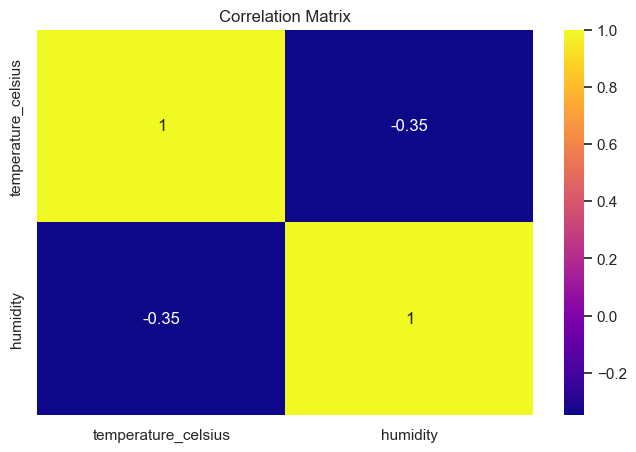

In [5]:
corr_matrix = df[["temperature_celsius", "humidity"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="plasma")
plt.title("Correlation Matrix")
plt.show()

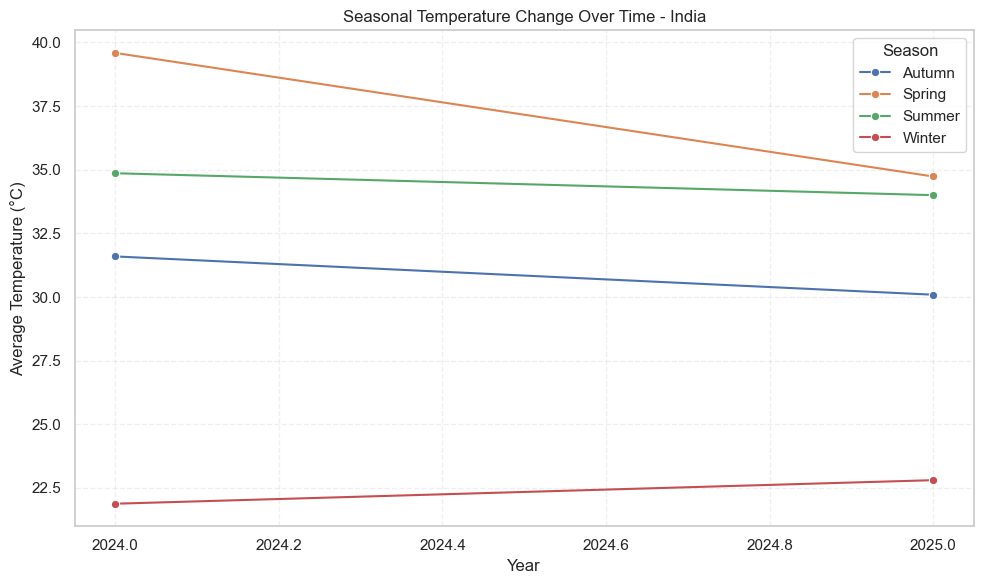

In [7]:
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
country_name = "India"   # <- set your country here
country_df = df[df['country'] == country_name].copy()

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

country_df['year'] = country_df['last_updated'].dt.year
country_df['month'] = country_df['last_updated'].dt.month
country_df['season'] = country_df['month'].apply(month_to_season)

seasonal_trends = (
    country_df
    .groupby(['year', 'season'])['temperature_celsius']
    .mean()
    .reset_index()
    .sort_values('year')
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=seasonal_trends,
    x='year',
    y='temperature_celsius',
    hue='season',
    marker='o'
)

plt.title(f"Seasonal Temperature Change Over Time - {country_name}")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [9]:
df['last_updated_dt'] = pd.to_datetime(df['last_updated_dt'], errors='coerce')


df = df.dropna(subset=['last_updated_dt'])

df['year'] = df['last_updated_dt'].dt.year
df['month'] = df['last_updated_dt'].dt.month     # 1–12

numeric_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col not in ['year', 'month']
]

monthly_avg = (
    df.groupby(['year', 'month'])[numeric_cols]
      .mean()
      .reset_index()
      .sort_values(['year', 'month'])
)

print(monthly_avg.head())

   year  month   latitude  longitude  last_updated_epoch  temperature_celsius  \
0  2024      5  19.330079  21.252653        1.716476e+09            25.153214   
1  2024      6  19.169585  21.786945        1.718494e+09            26.456036   
2  2024      7  19.090607  22.195843        1.721096e+09            26.800448   
3  2024      8  19.107315  22.088584        1.723808e+09            26.789677   
4  2024      9  19.064397  22.147510        1.726441e+09            25.124402   

   temperature_fahrenheit  wind_mph   wind_kph  wind_degree  ...  \
0               77.275500  8.897635  14.322680   170.234384  ...   
1               79.622507  9.127415  14.694197   178.421044  ...   
2               80.242645  8.684089  13.979538   183.502419  ...   
3               80.223093  8.643540  13.915649   180.594045  ...   
4               77.226417  8.222507  13.235980   169.814720  ...   

   air_quality_Carbon_Monoxide  air_quality_Ozone  \
0                   527.585263          60.698423  

In [11]:
numeric_cols = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph']

country_compare = (
    df.groupby('country')[numeric_cols]
      .mean()
      .reset_index()
)

print(country_compare.head())

       country  temperature_celsius   humidity  pressure_mb   wind_kph
0  Afghanistan            21.560799  23.392015  1009.328494   9.394737
1      Albania            22.358076  51.637024  1015.822142   9.178403
2      Algeria            23.035818  59.590909  1017.290909  12.759636
3      Andorra            12.021960  59.446461  1017.989111   8.360436
4       Angola            26.145735  73.279492  1013.148820   9.513067



========== EXTREME EVENTS: temperature_celsius ==========


Highest Events:
      country location_name     last_updated_dt  temperature_celsius
6896   Kuwait   Kuwait City 2024-06-19 16:45:00                 49.2
7460     Iraq       Baghdad 2024-06-22 16:45:00                 49.1
11145    Iraq       Baghdad 2024-07-11 15:45:00                 49.1
8425   Kuwait   Kuwait City 2024-06-27 16:15:00                 48.9
11338    Iraq       Baghdad 2024-07-12 15:45:00                 48.8
85049  Kuwait   Kuwait City 2025-07-28 11:30:00                 48.8
76862  Kuwait   Kuwait City 2025-06-16 12:00:00                 48.6
7270     Iraq       Baghdad 2024-06-21 16:30:00                 48.4
9975     Iraq       Baghdad 2024-07-05 15:45:00                 48.3
88168  Kuwait   Kuwait City 2025-08-13 11:30:00                 48.2


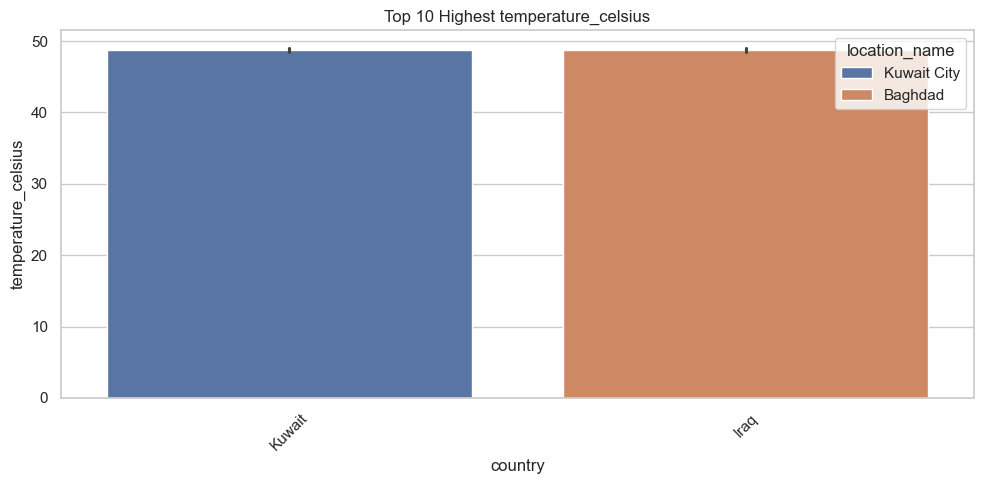


Lowest Events:
          country location_name     last_updated_dt  temperature_celsius
51564    Mongolia   Ulaanbaatar 2025-02-06 18:15:00                -24.9
44583    Mongolia   Ulaanbaatar 2025-01-01 18:00:00                -24.8
43218    Mongolia   Ulaanbaatar 2024-12-25 18:15:00                -24.2
47081    Mongolia   Ulaanbaatar 2025-01-14 19:00:00                -23.8
48808  Kazakhstan        Astana 2025-01-23 15:30:00                -23.8
49003  Kazakhstan        Astana 2025-01-24 15:30:00                -23.6
43413    Mongolia   Ulaanbaatar 2024-12-26 18:00:00                -23.4
45911    Mongolia   Ulaanbaatar 2025-01-08 19:15:00                -23.4
50589    Mongolia   Ulaanbaatar 2025-02-01 18:30:00                -23.0
40683    Mongolia   Ulaanbaatar 2024-12-12 18:45:00                -22.9


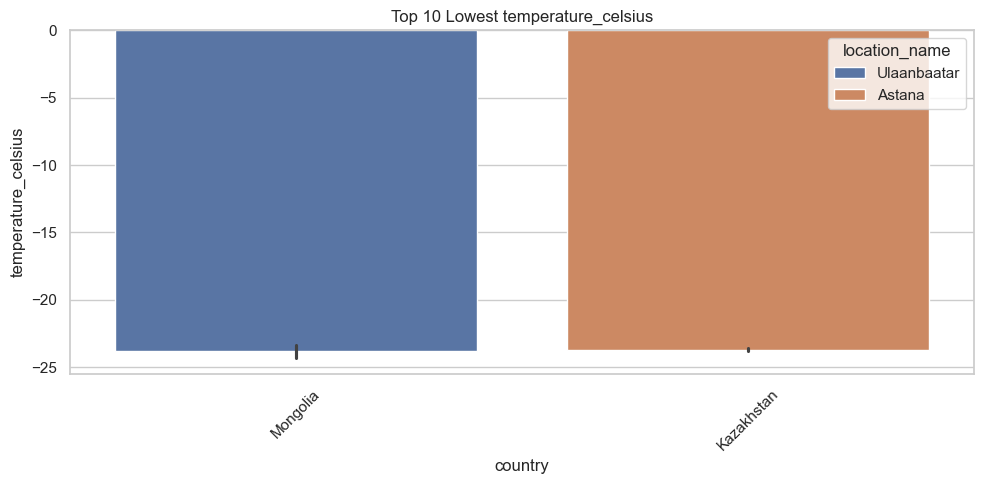

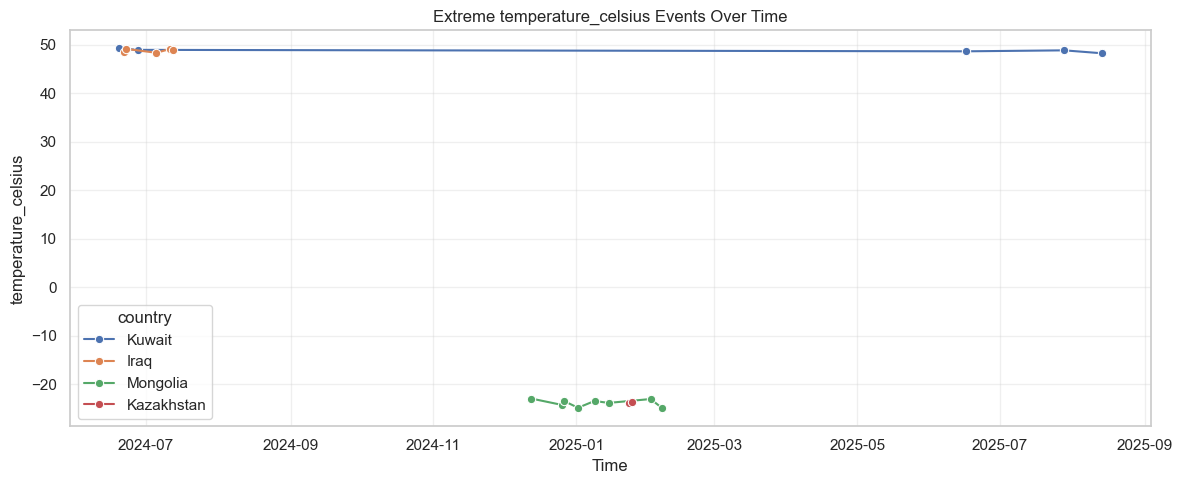


========== EXTREME EVENTS: humidity ==========


Highest Events:
               country        location_name     last_updated_dt  humidity
40          Costa Rica             San Juan 2024-05-16 02:45:00       100
71              Guyana           Georgetown 2024-05-16 04:45:00       100
176              Tonga           Nuku`Aloia 2024-05-16 21:45:00       100
181             Tuvalu             Funafuti 2024-05-16 20:45:00       100
203          Australia             Canberra 2024-05-17 00:00:00       100
219  Brunei Darussalam  Bandar Seri Begawan 2024-05-16 22:00:00       100
253       Fiji Islands                 Suva 2024-05-17 02:00:00       100
298           Malaysia         Kuala Lumpur 2024-05-16 22:00:00       100
330   Papua New Guinea         Port Moresby 2024-05-17 00:15:00       100
364        Switzerland                 Bern 2024-05-16 16:15:00       100


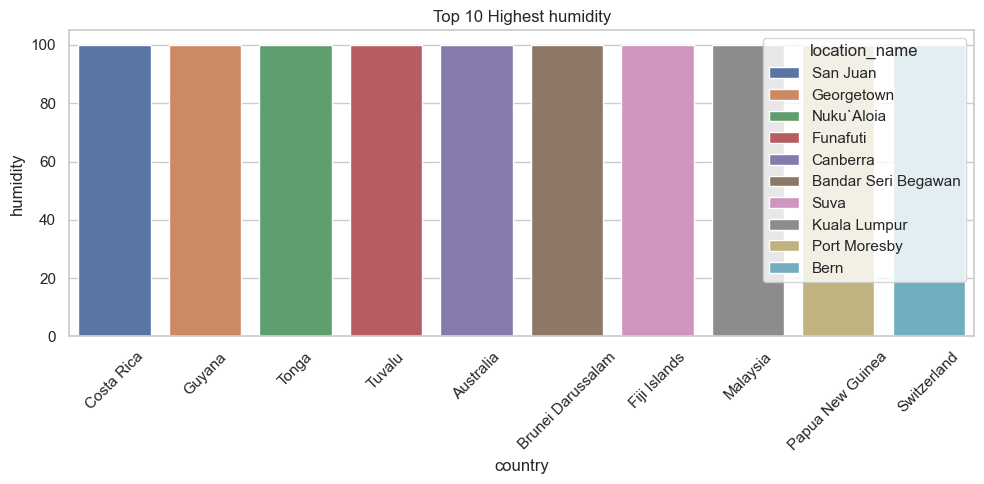


Lowest Events:
            country location_name     last_updated_dt  humidity
13448       Namibia      Windhoek 2024-07-25 14:15:00         2
16372       Namibia      Windhoek 2024-08-09 14:30:00         2
4824   Saudi Arabia        Riyadh 2024-06-08 17:15:00         3
7149   Saudi Arabia        Riyadh 2024-06-20 16:45:00         3
9071   Saudi Arabia        Riyadh 2024-06-30 16:30:00         3
13253       Namibia      Windhoek 2024-07-24 14:45:00         3
13838       Namibia      Windhoek 2024-07-27 14:30:00         3
24366       Namibia      Windhoek 2024-09-19 12:45:00         3
76923  Saudi Arabia        Riyadh 2025-06-16 12:00:00         3
2502          Sudan      Khartoum 2024-05-27 16:30:00         4


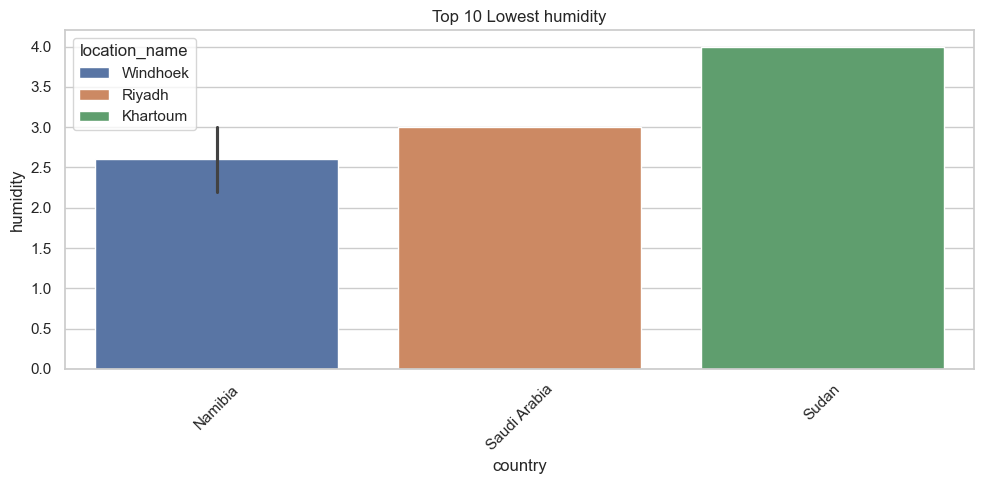

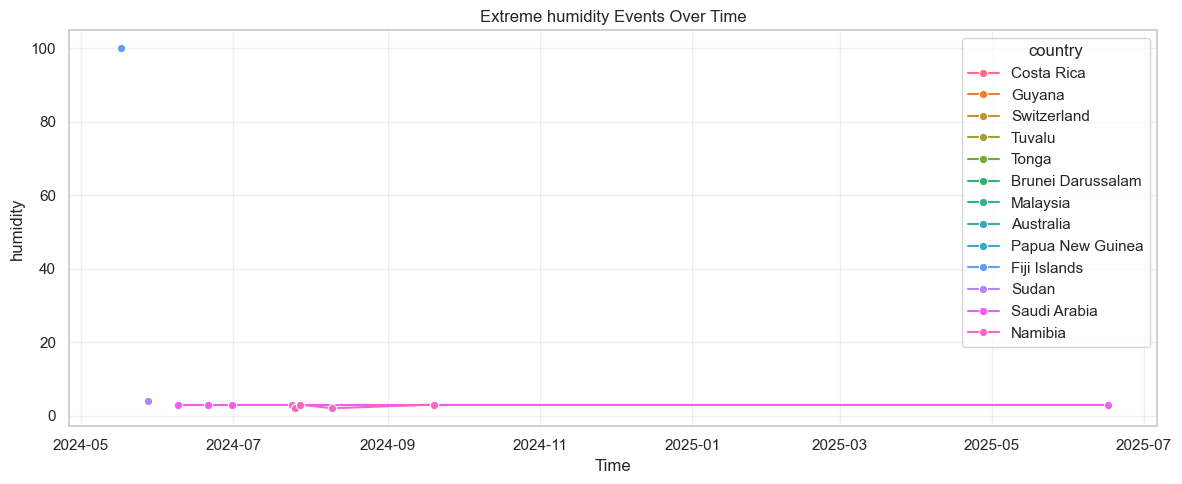


========== EXTREME EVENTS: wind_kph ==========


Highest Events:
                     country   location_name     last_updated_dt  wind_kph
7601                 Burundi       Bujumbura 2024-06-23 15:45:00    2963.2
7248                Ethiopia     Addis Ababa 2024-06-21 16:30:00     272.2
1193                 Burundi       Bujumbura 2024-05-21 16:45:00     258.8
8675   Saint Kitts and Nevis      Basseterre 2024-06-28 09:15:00     205.9
834             Fiji Islands            Suva 2024-05-20 02:00:00     172.1
51526                Iceland  Vestmannaeyjar 2025-02-06 10:15:00      91.1
9129                Barbados      Bridgetown 2024-07-01 09:15:00      81.0
19892                 Norway            Oslo 2024-08-27 14:15:00      78.1
35380                Iceland  Vestmannaeyjar 2024-11-15 09:00:00      76.7
22816                 Norway            Oslo 2024-09-11 14:15:00      76.0


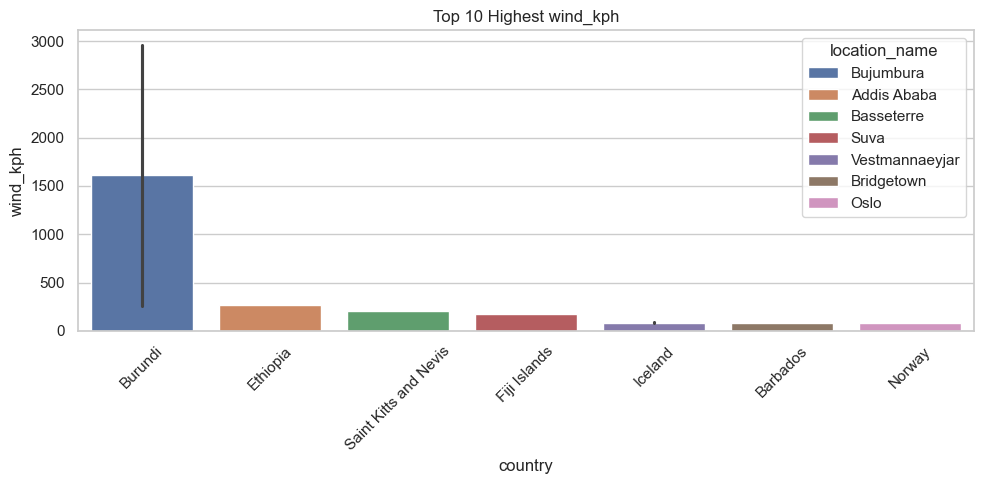


Lowest Events:
                   country location_name     last_updated_dt  wind_kph
6                Argentina  Buenos Aires 2024-05-16 05:45:00       3.6
20                 Bolivia         Sucre 2024-05-16 04:45:00       3.6
21  Bosnia and Herzegovina      Sarajevo 2024-05-16 10:45:00       3.6
27                 Burundi     Bujumbura 2024-05-16 10:45:00       3.6
31                Cameroon       Yaounde 2024-05-16 09:45:00       3.6
40              Costa Rica      San Juan 2024-05-16 02:45:00       3.6
52             El Salvador  San Salvador 2024-05-16 02:45:00       3.6
66                  Greece        Athens 2024-05-16 11:45:00       3.6
69                  Guinea       Conakry 2024-05-16 08:45:00       3.6
71                  Guyana    Georgetown 2024-05-16 04:45:00       3.6


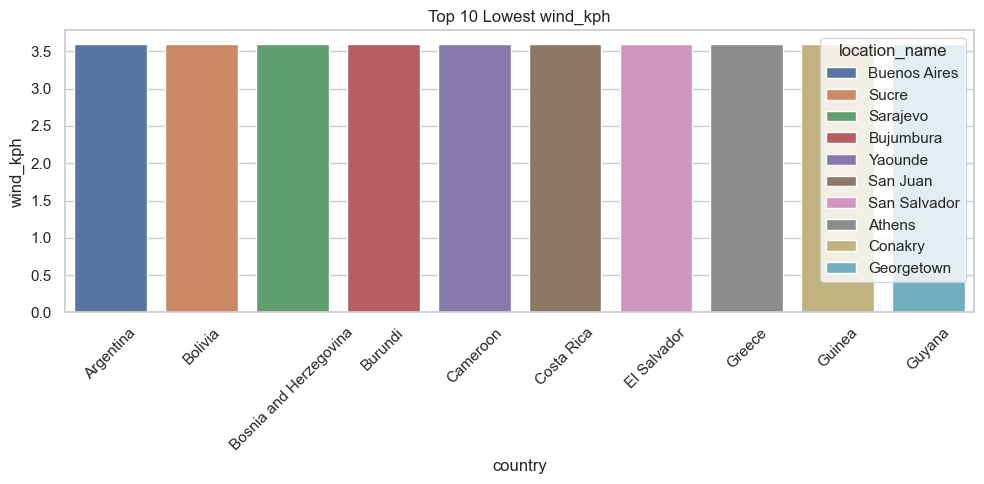

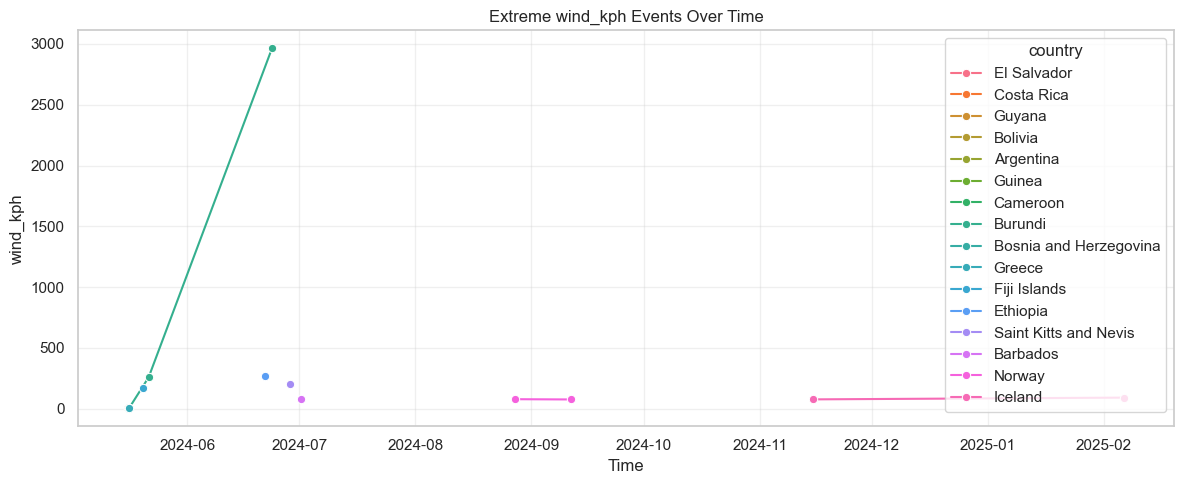


========== EXTREME EVENTS: pressure_mb ==========


Highest Events:
          country location_name     last_updated_dt  pressure_mb
49769    Honduras   Tegucigalpa 2025-01-28 05:00:00         3006
52114        Iran        Tehran 2025-02-09 14:00:00         3000
38510      Jordan         Amman 2024-12-01 14:00:00         1080
49003  Kazakhstan        Astana 2025-01-24 15:30:00         1052
51704     Finland      Helsinki 2025-02-07 12:30:00         1052
51700     Estonia       Tallinn 2025-02-07 12:30:00         1051
51788      Russia        Moscow 2025-02-07 13:30:00         1051
40071  Kazakhstan        Astana 2024-12-09 16:00:00         1050
51738      Latvia          Riga 2025-02-07 12:30:00         1050
51983      Russia        Moscow 2025-02-08 13:30:00         1050


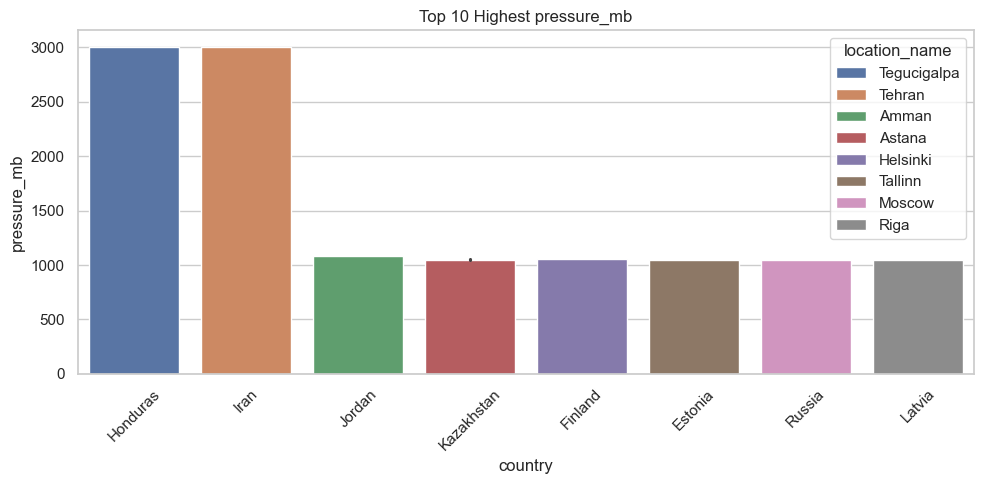


Lowest Events:
        country   location_name     last_updated_dt  pressure_mb
50941   Iceland  Vestmannaeyjar 2025-02-03 10:30:00          947
54839   Iceland  Vestmannaeyjar 2025-02-23 10:00:00          962
49582   Ireland          Dublin 2025-01-27 10:30:00          964
54449   Iceland  Vestmannaeyjar 2025-02-21 10:00:00          964
55034   Iceland  Vestmannaeyjar 2025-02-24 10:00:00          964
54644   Iceland  Vestmannaeyjar 2025-02-22 10:00:00          969
30172   Iceland  Vestmannaeyjar 2024-10-19 09:30:00          971
45744    Norway            Oslo 2025-01-07 11:00:00          972
48992   Iceland  Vestmannaeyjar 2025-01-24 10:30:00          973
103749  Iceland       Reykjavik 2025-11-01 08:00:00          973


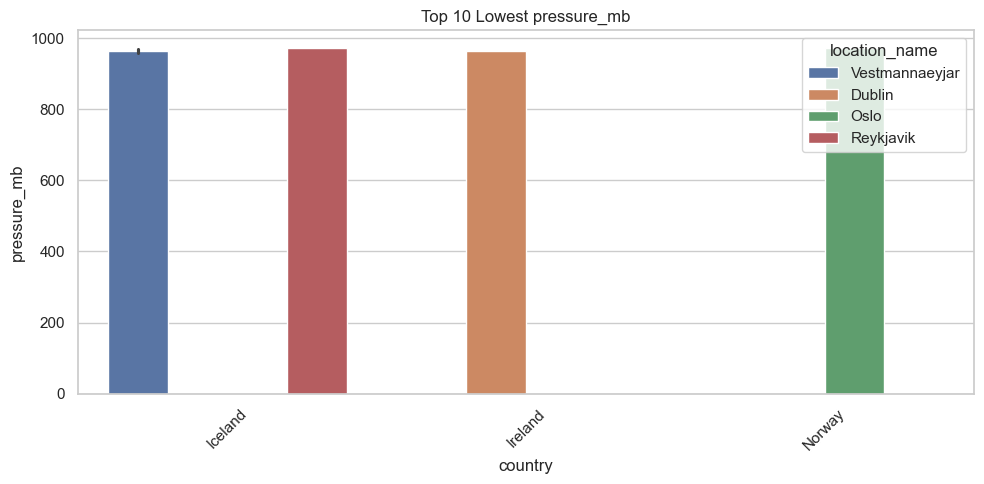

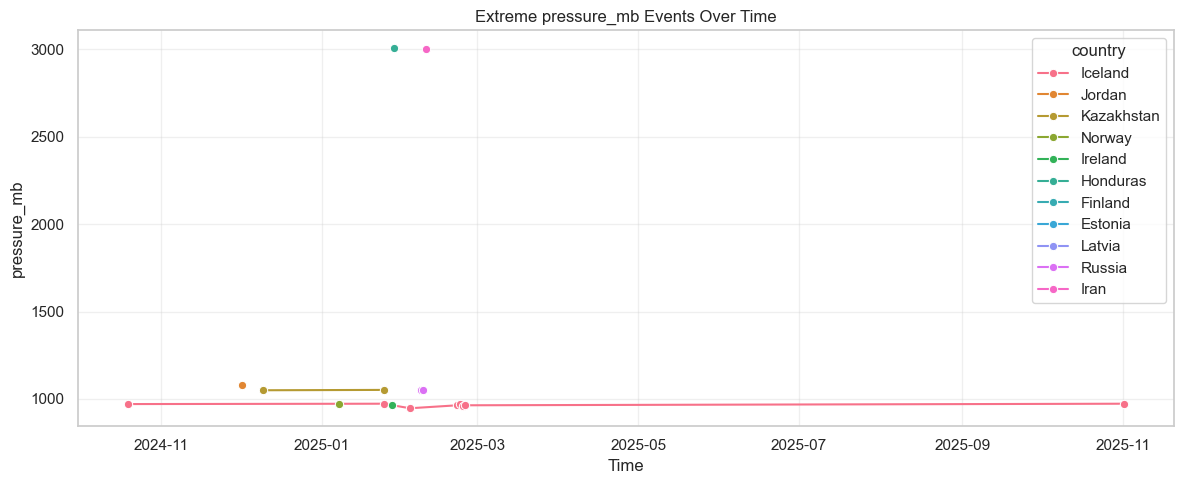

In [13]:
params = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']

top_n = 10 

for col in params:
    print(f"\n========== EXTREME EVENTS: {col} ==========\n")

    # Highest Events
    highest = df.nlargest(top_n, col)[['country', 'location_name', 'last_updated_dt', col]]
    print("\nHighest Events:")
    print(highest)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=highest, x='country', y=col, hue='location_name')
    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} Highest {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Lowest Events
    lowest = df.nsmallest(top_n, col)[['country', 'location_name', 'last_updated_dt', col]]
    print("\nLowest Events:")
    print(lowest)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=lowest, x='country', y=col, hue='location_name')
    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} Lowest {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Trend over time of Extremes
    combined = pd.concat([highest, lowest]).sort_values("last_updated_dt")

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=combined,
        x='last_updated_dt',
        y=col,
        hue='country',
        marker='o'
    )
    plt.title(f"Extreme {col} Events Over Time")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

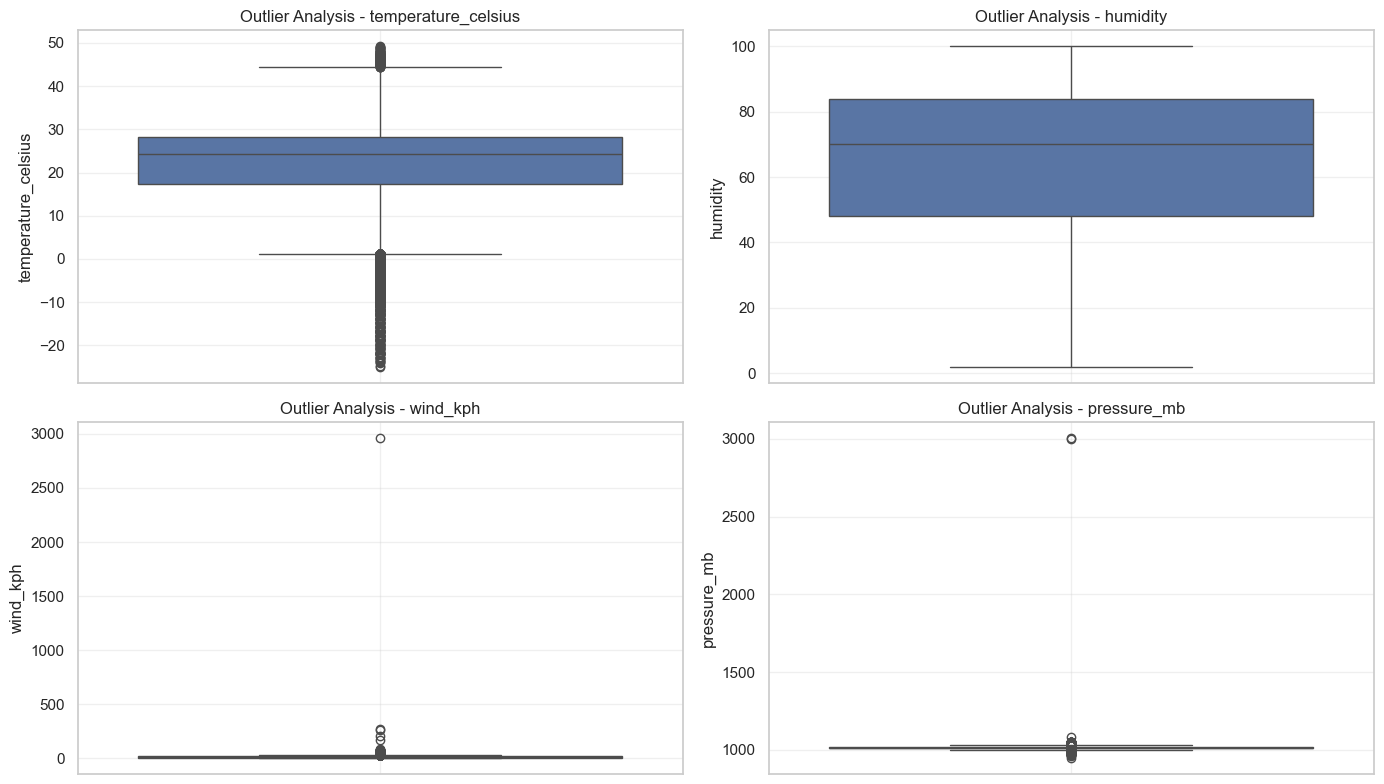

In [15]:
params = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']

plt.figure(figsize=(14, 8))

for i, col in enumerate(params, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, y=col)
    plt.title(f"Outlier Analysis - {col}")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
window = 24  

spike_results = {}

for col in params:
    # Rolling stats
    df[f'{col}_roll_mean'] = df[col].rolling(window=window, min_periods=5, center=True).mean()
    df[f'{col}_roll_std']  = df[col].rolling(window=window, min_periods=5, center=True).std()

    df[f'{col}_zscore'] = (df[col] - df[f'{col}_roll_mean']) / df[f'{col}_roll_std']

    spike_threshold = 3 

    spikes = df[df[f'{col}_zscore'].abs() > spike_threshold].copy()

    spike_results[col] = spikes[['country', 'location_name', 'last_updated_dt', col, f'{col}_zscore']]

    print(f"\n===== SPIKES DETECTED IN {col}: {len(spikes)} EVENTS =====")
    print(spike_results[col].head())




===== SPIKES DETECTED IN temperature_celsius: 256 EVENTS =====
                       country    location_name     last_updated_dt  \
1076                      Mali           Bamako 2024-05-20 14:45:00   
2292              Saudi Arabia           Riyadh 2024-05-26 17:15:00   
3106  United States of America  Washington Park 2024-05-30 06:45:00   
4876                 Australia         Canberra 2024-06-10 00:15:00   
6189              Saudi Arabia           Riyadh 2024-06-15 17:00:00   

      temperature_celsius  temperature_celsius_zscore  
1076                 42.0                    3.019096  
2292                 43.0                    3.109440  
3106                  2.8                   -3.162174  
4876                  1.1                   -3.094155  
6189                 43.2                    3.148482  

===== SPIKES DETECTED IN humidity: 70 EVENTS =====
            country location_name     last_updated_dt  humidity  \
34870  Saudi Arabia        Riyadh 2024-11-12 12:00:00 

                          temperature_celsius   humidity  precip_mm  \
country                                                               
Iceland                              6.622909  81.734545   0.184073   
Mongolia                             7.182332  50.045537   0.047359   
Canada                               7.831569  84.790146   0.162336   
United States of America             9.260367  89.168807   0.046532   
Norway                               9.749636  74.907273   0.096109   
...                                       ...        ...        ...   
United Arab Emirates                34.219782  41.462795   0.000181   
Qatar                               34.403818  37.360000   0.000418   
Turkménistan                        37.800000  11.000000   0.000000   
Marrocos                            40.300000  14.000000   0.000000   
Saudi Arabien                       45.000000   7.000000   0.000000   

                           wind_kph  pressure_mb  
country                  

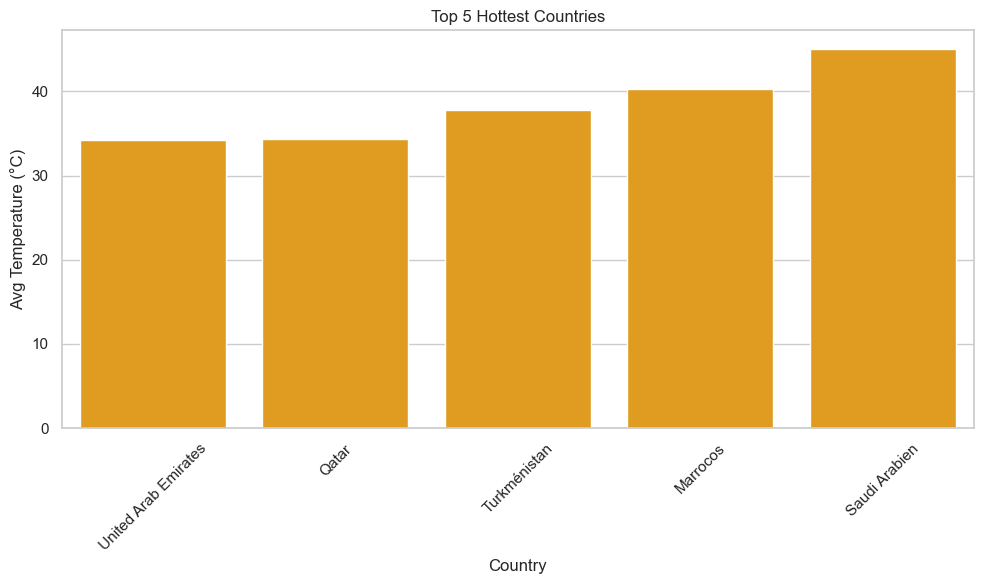

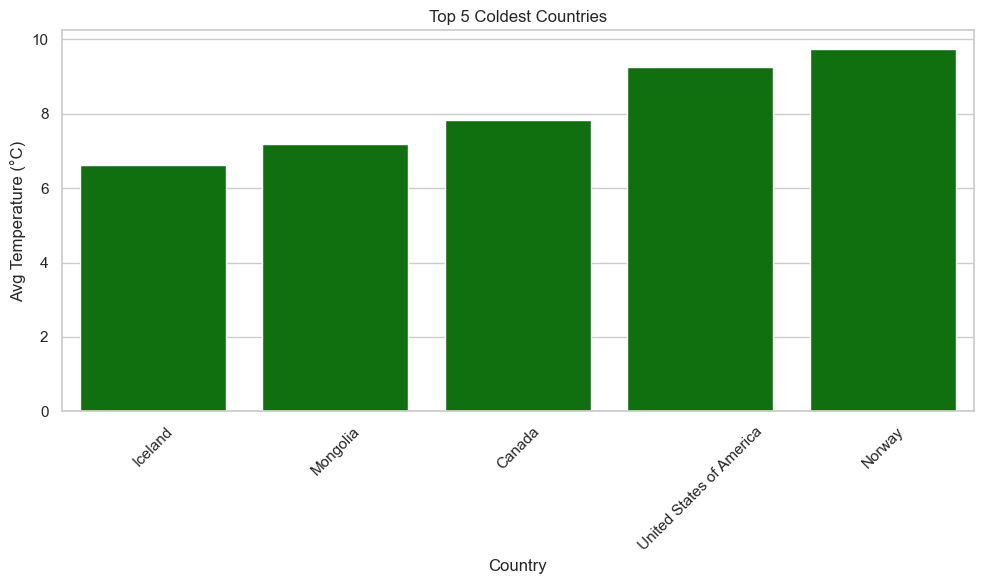

In [25]:
country_stats = (
    df.groupby('country')[['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph', 'pressure_mb']]
      .mean()
      .sort_values('temperature_celsius')
)

print(country_stats)

# Top 5 coldest and hottest countries
coldest_countries = country_stats.head(5)['temperature_celsius']
hottest_countries = country_stats.tail(5)['temperature_celsius']

print("\nTop 5 Coldest Countries:\n", coldest_countries)
print("\nTop 5 Hottest Countries:\n", hottest_countries)

# Visualization - Hottest Countries (Orange)
plt.figure(figsize=(10, 6))
sns.barplot(x=hottest_countries.index, y=hottest_countries.values, color="orange")
plt.title("Top 5 Hottest Countries")
plt.xlabel("Country")
plt.ylabel("Avg Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization - Coldest Countries (Green)
plt.figure(figsize=(10, 6))
sns.barplot(x=coldest_countries.index, y=coldest_countries.values, color="green")
plt.title("Top 5 Coldest Countries")
plt.xlabel("Country")
plt.ylabel("Avg Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()